In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("Cardiotocographic.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst Five Records:")
display(df.head())

Shape of Dataset:
(2126, 14)

Column Names:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']

First Five Records:


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
LB,21,0.987770
AC,20,0.940734
FM,0,0.000000
UC,0,0.000000
DL,0,0.000000
DS,21,0.987770
DP,21,0.987770
ASTV,0,0.000000
MSTV,0,0.000000
ALTV,0,0.000000


In [7]:
print("Duplicate Records:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Duplicate Records: 2
Shape after removing duplicates: (2124, 14)


In [8]:
for col in df.columns:
    
    if df[col].dtype != 'object':
        df[col].fillna(df[col].median(), inplace=True)
        
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing Values After Treatment")

df.isnull().sum()

Missing Values After Treatment


C:\Users\akshara\AppData\Local\Temp\ipykernel_1928\3589432748.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
LB,2124.0,133.338641,11.212447,51.842487,126.000000,133.000000,140.000000,214.000000
AC,2124.0,0.003205,0.004374,-0.019284,0.000000,0.001634,0.005612,0.038567
FM,2124.0,0.009904,0.067571,-0.480634,0.000000,0.000000,0.002568,0.961268
UC,2124.0,0.004394,0.003340,-0.014925,0.001858,0.004486,0.006536,0.030002
DL,2124.0,0.001897,0.003344,-0.015393,0.000000,0.000000,0.003292,0.030769
DS,2124.0,0.000002,0.000141,-0.001353,0.000000,0.000000,0.000000,0.002706
DP,2124.0,0.000174,0.000836,-0.005348,0.000000,0.000000,0.000000,0.010695
ASTV,2124.0,47.012459,18.812403,-63.000000,32.000000,49.000000,61.000000,162.000000
MSTV,2124.0,1.364345,1.174084,-6.600000,0.700000,1.200000,1.700000,13.800000
ALTV,2124.0,10.295650,21.212676,-91.000000,0.000000,0.000000,11.000000,182.000000


In [10]:
summary = pd.DataFrame()

summary["Mean"] = df.mean(numeric_only=True)
summary["Median"] = df.median(numeric_only=True)
summary["Std Deviation"] = df.std(numeric_only=True)

summary

,Mean,Median,Std Deviation
LB,133.338641,133.000000,11.212447
AC,0.003205,0.001634,0.004374
FM,0.009904,0.000000,0.067571
UC,0.004394,0.004486,0.003340
DL,0.001897,0.000000,0.003344
DS,0.000002,0.000000,0.000141
DP,0.000174,0.000000,0.000836
ASTV,47.012459,49.000000,18.812403
MSTV,1.364345,1.200000,1.174084
ALTV,10.295650,0.000000,21.212676


In [11]:
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)

IQR = Q3 - Q1

iqr_table = pd.DataFrame({
    "Q1":Q1,
    "Q3":Q3,
    "IQR":IQR
})

iqr_table

,Q1,Q3,IQR
LB,126.000000,140.000000,14.000000
AC,0.000000,0.005612,0.005612
FM,0.000000,0.002568,0.002568
UC,0.001858,0.006536,0.004678
DL,0.000000,0.003292,0.003292
DS,0.000000,0.000000,0.000000
DP,0.000000,0.000000,0.000000
ASTV,32.000000,61.000000,29.000000
MSTV,0.700000,1.700000,1.000000
ALTV,0.000000,11.000000,11.000000


In [12]:
outlier_count = {}

for col in df.select_dtypes(include=np.number).columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col]<lower) | (df[col]>upper)]

    outlier_count[col] = len(outliers)

pd.DataFrame(outlier_count.items(),
             columns=["Feature","Outlier Count"])

,Feature,Outlier Count
0,LB,10
1,AC,42
2,FM,347
3,UC,13
4,DL,125
5,DS,120
6,DP,284
7,ASTV,10
8,MSTV,80
9,ALTV,318


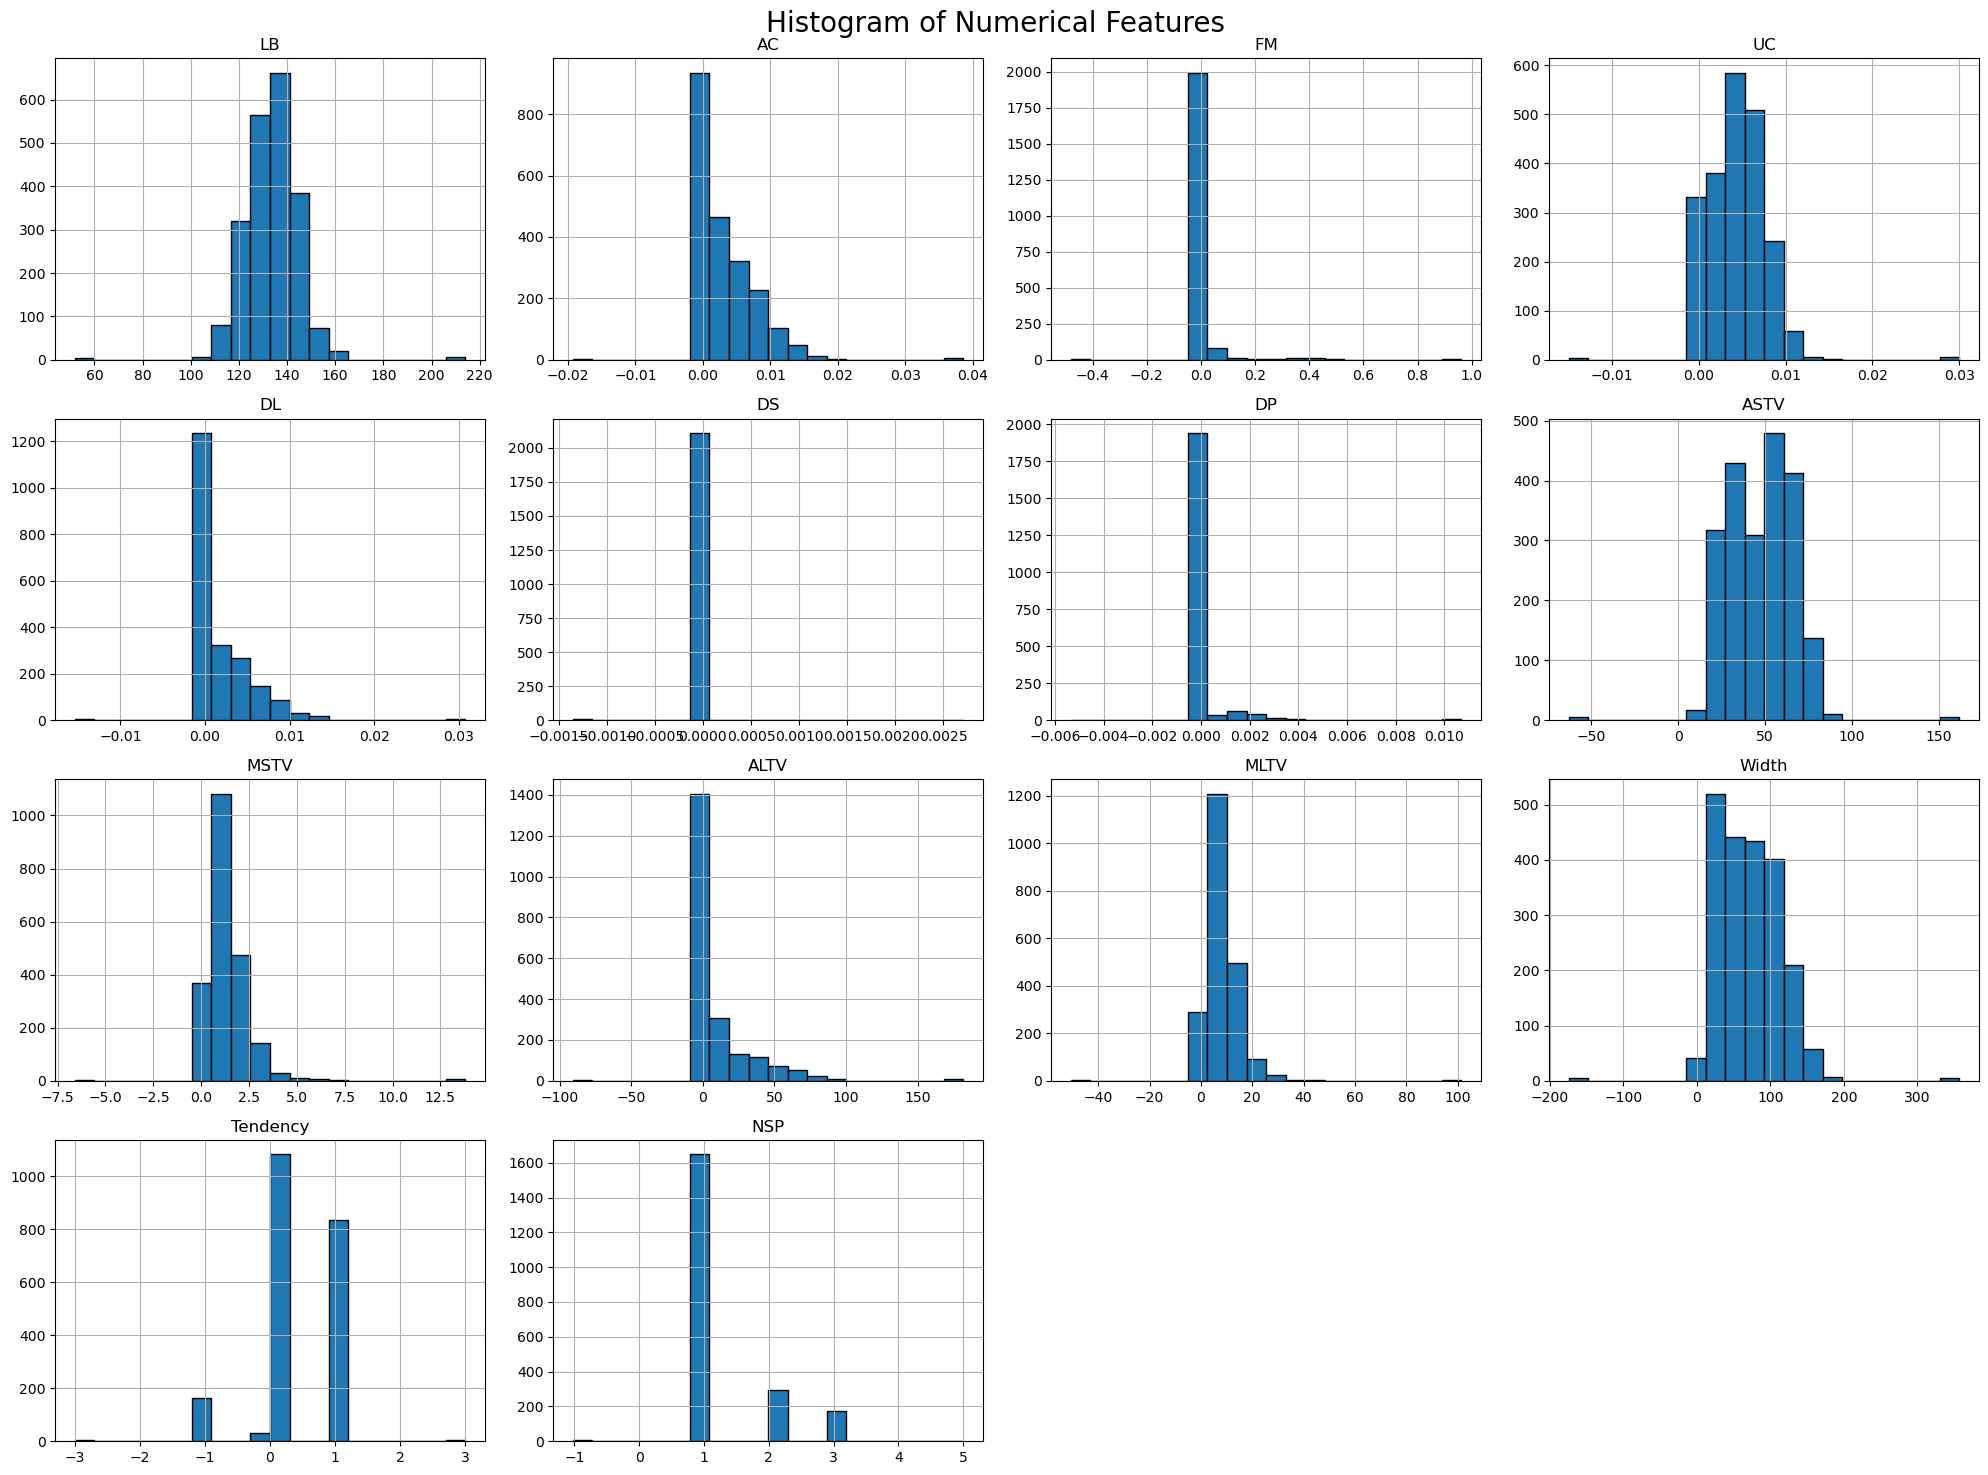

In [13]:
df.hist(
    figsize=(20,15),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histogram of Numerical Features", fontsize=20)
plt.tight_layout()
plt.show()

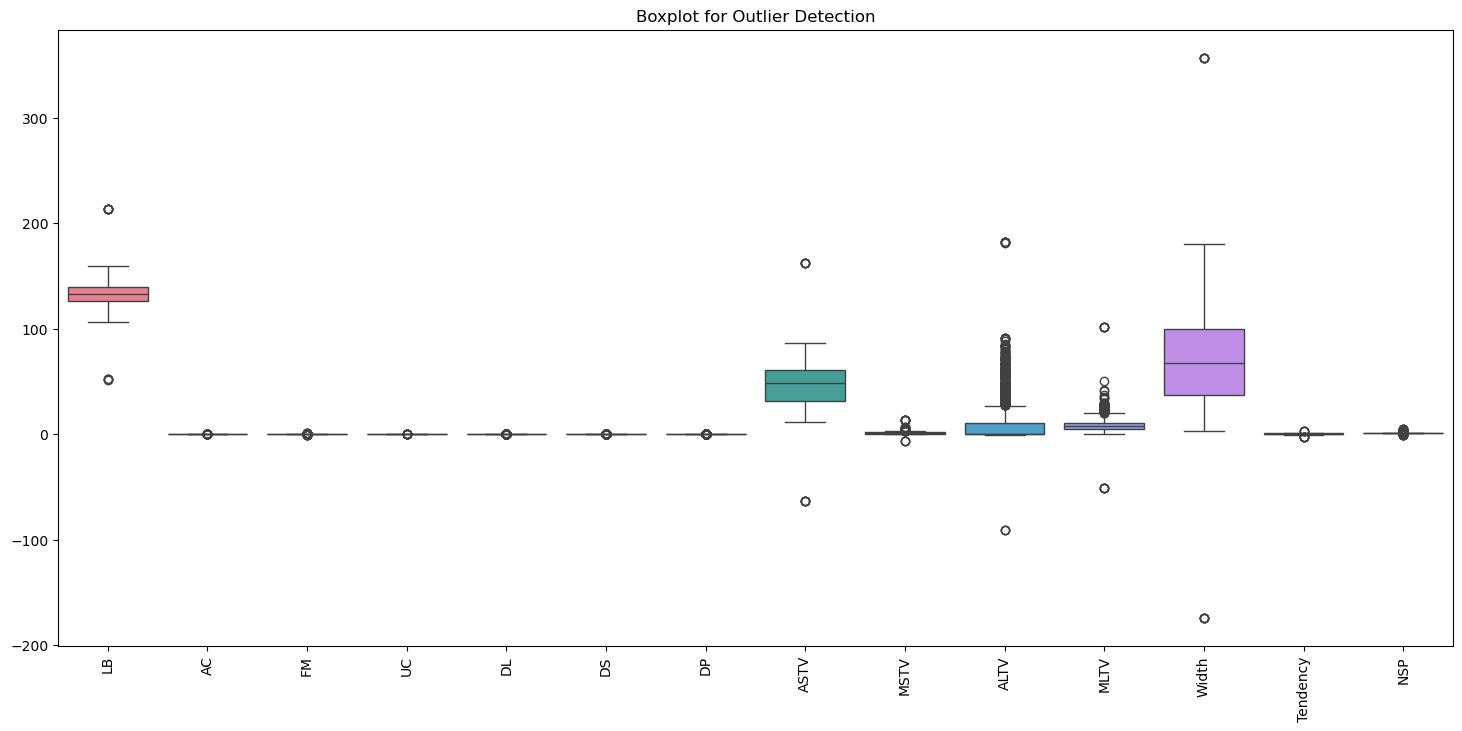

In [14]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplot for Outlier Detection")

plt.show()

In [15]:
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.063425,0.018839,-0.166669,-0.126585,-0.005433,-0.047653,0.241667,-0.169310,0.210769,-0.003190,-0.118351,0.236976,0.132003
AC,-0.063425,1.000000,0.009743,0.071313,-0.093581,-0.033097,-0.083350,-0.231086,0.133215,-0.269967,-0.104635,0.234541,0.031630,-0.311855
FM,0.018839,0.009743,1.000000,-0.053386,0.009641,0.029914,0.121434,-0.032838,0.017061,-0.012005,-0.006041,0.097193,-0.017888,0.074389
UC,-0.166669,0.071313,-0.053386,1.000000,0.189737,-0.006958,0.070144,-0.182379,0.189685,-0.227881,-0.048854,0.106485,-0.067314,-0.185766
DL,-0.126585,-0.093581,0.009641,0.189737,1.000000,0.058413,0.144631,-0.069907,0.410216,-0.187275,-0.165035,0.408354,-0.024180,0.024634
DS,-0.005433,-0.033097,0.029914,-0.006958,0.058413,1.000000,0.004317,0.008415,0.016028,-0.004344,0.034384,0.040842,-0.015304,0.065410
DP,-0.047653,-0.083350,0.121434,0.070144,0.144631,0.004317,1.000000,0.037959,0.118647,-0.077079,-0.113728,0.175341,-0.129316,0.295002
ASTV,0.241667,-0.231086,-0.032838,-0.182379,-0.069907,0.008415,0.037959,1.000000,-0.293820,0.357310,-0.219204,-0.207769,-0.011289,0.420738
MSTV,-0.169310,0.133215,0.017061,0.189685,0.410216,0.016028,0.118647,-0.293820,1.000000,-0.291979,0.028326,0.433024,-0.038010,-0.095881
ALTV,0.210769,-0.269967,-0.012005,-0.227881,-0.187275,-0.004344,-0.077079,0.357310,-0.291979,1.000000,-0.106963,-0.346267,0.038019,0.366318


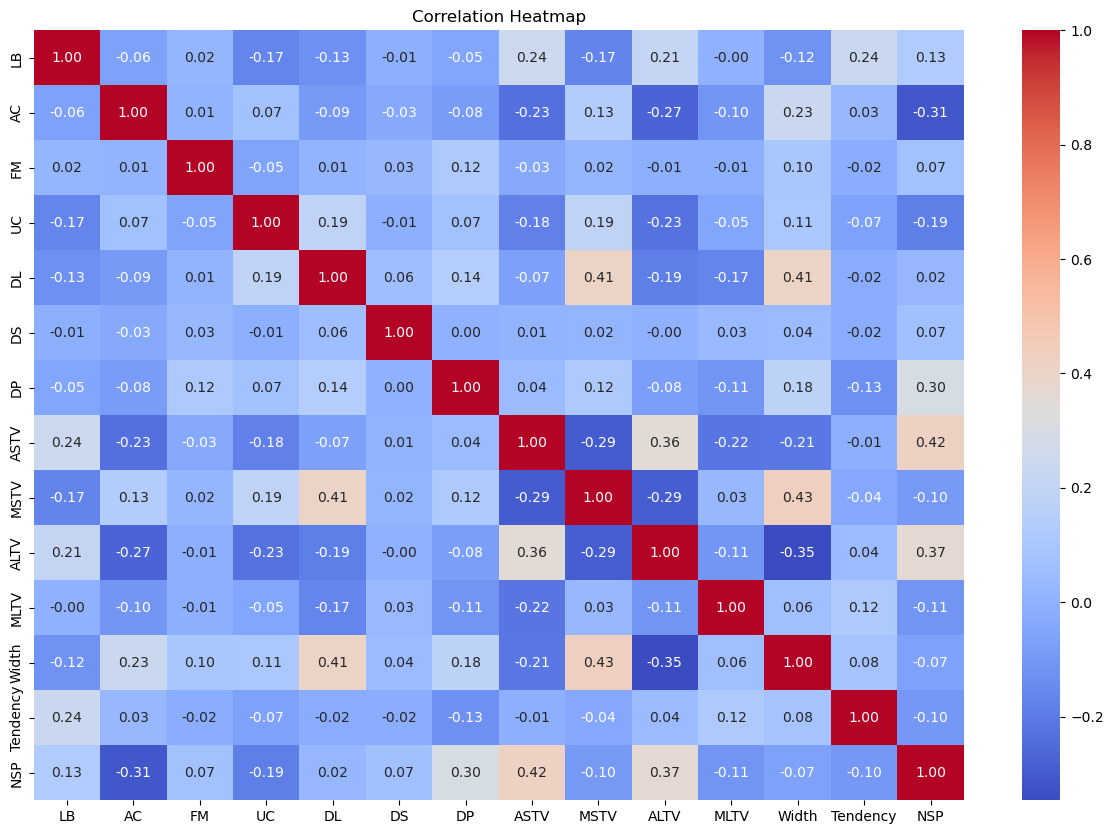

In [16]:
plt.figure(figsize=(15,10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

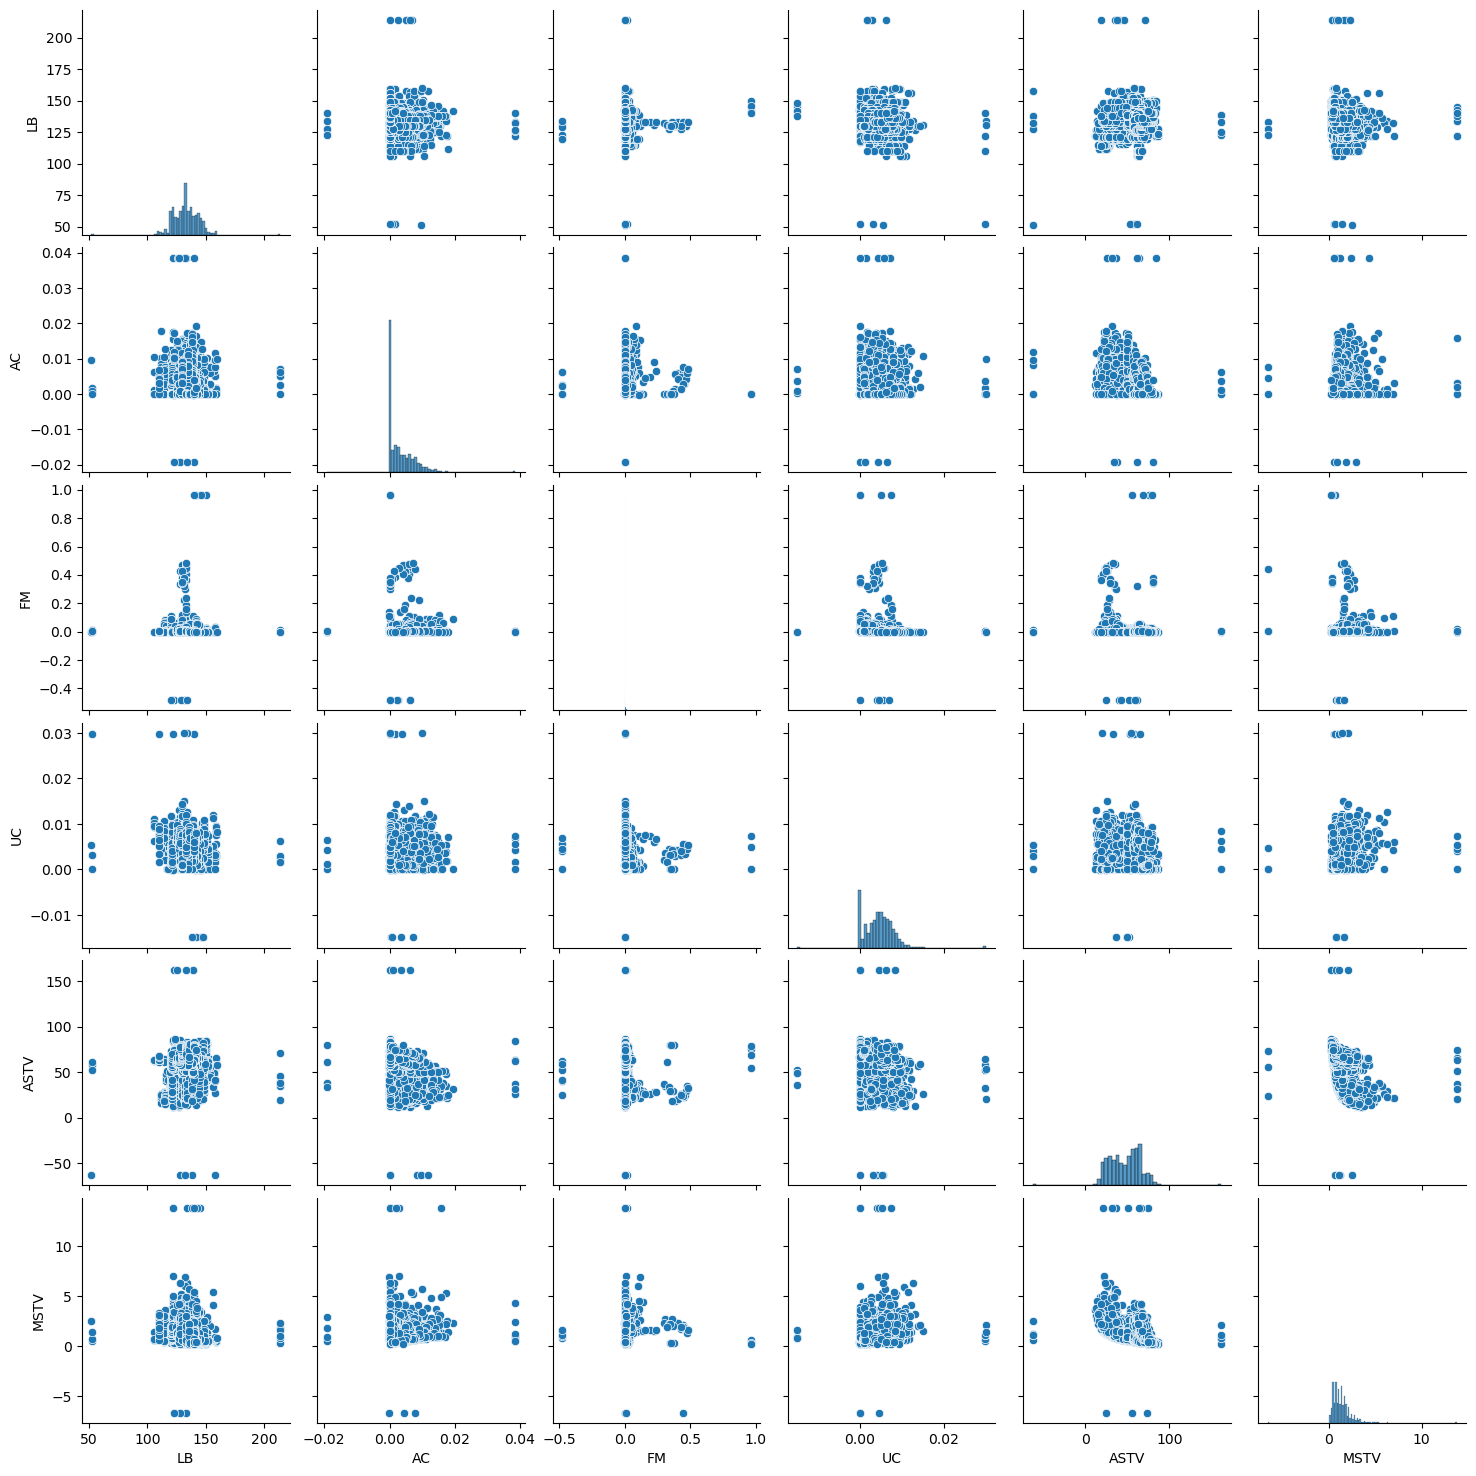

In [17]:
selected_features = [
    'LB',
    'AC',
    'FM',
    'UC',
    'ASTV',
    'MSTV'
]

sns.pairplot(df[selected_features])

plt.show()

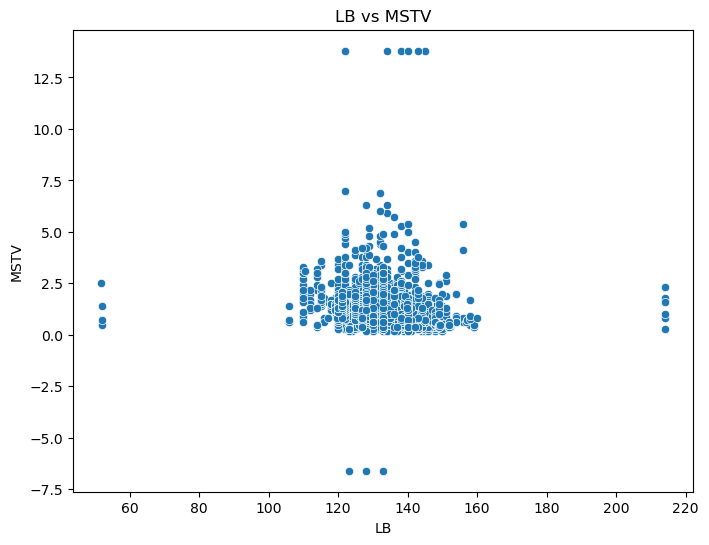

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='LB',
    y='MSTV'
)

plt.title("LB vs MSTV")

plt.show()

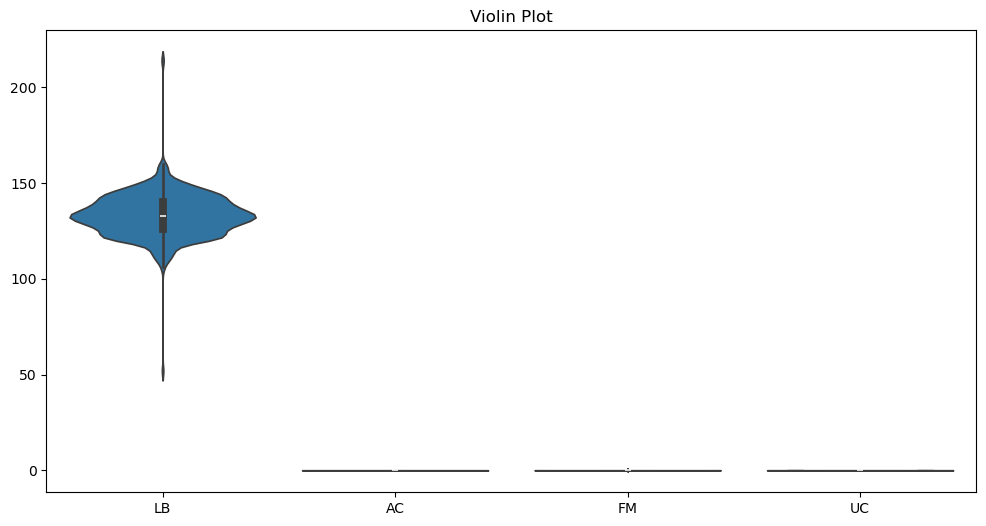

In [19]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df[['LB','AC','FM','UC']]
)

plt.title("Violin Plot")

plt.show()

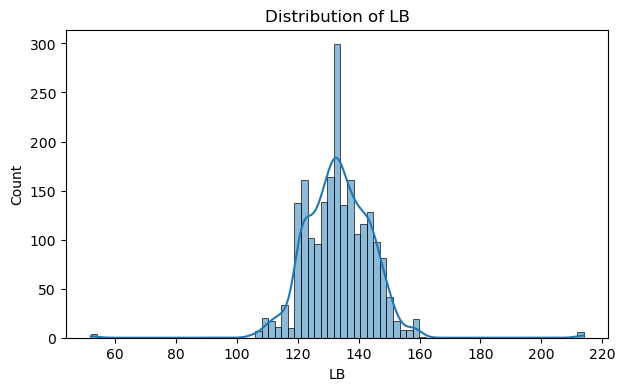

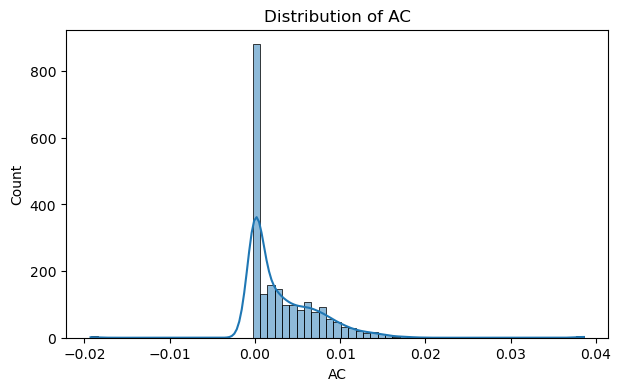

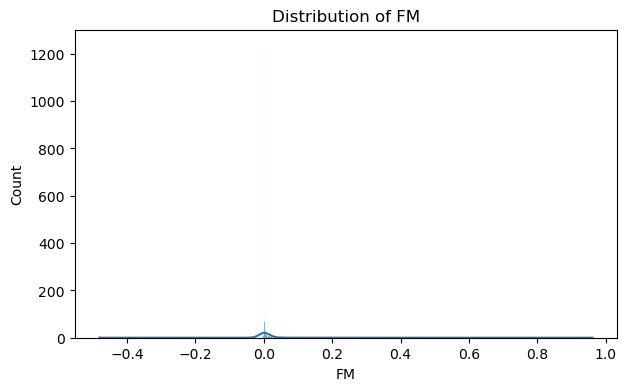

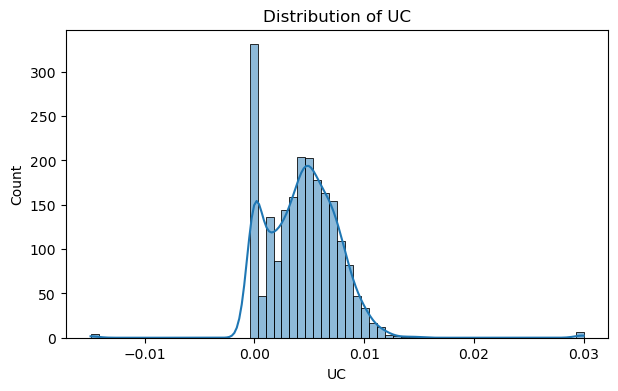

In [20]:
features = ['LB','AC','FM','UC']

for feature in features:

    plt.figure(figsize=(7,4))

    sns.histplot(
        df[feature],
        kde=True
    )

    plt.title(f"Distribution of {feature}")

    plt.show()

In [21]:
corr = df.corr(numeric_only=True)

corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    ascending=False
)

corr_pairs.drop_duplicates().head(30)

LB        LB          1.000000
Width     MSTV        0.433024
NSP       ASTV        0.420738
DL        MSTV        0.410216
Width     DL          0.408354
NSP       ALTV        0.366318
ALTV      ASTV        0.357310
NSP       DP          0.295002
LB        ASTV        0.241667
          Tendency    0.236976
Width     AC          0.234541
ALTV      LB          0.210769
UC        DL          0.189737
MSTV      UC          0.189685
Width     DP          0.175341
DP        DL          0.144631
AC        MSTV        0.133215
NSP       LB          0.132003
FM        DP          0.121434
DP        MSTV        0.118647
MLTV      Tendency    0.117075
Width     UC          0.106485
          FM          0.097193
Tendency  Width       0.081263
FM        NSP         0.074389
AC        UC          0.071313
DP        UC          0.070144
NSP       DS          0.065410
Width     MLTV        0.059104
DL        DS          0.058413
dtype: float64

In [22]:
skewness = pd.DataFrame({
    "Skewness":df.skew(numeric_only=True)
})

skewness.sort_values(
    by="Skewness",
    ascending=False
)

,Skewness
DS,8.457283
FM,6.749691
DP,6.453124
MSTV,4.141709
MLTV,3.563587
ALTV,2.979526
AC,2.032003
DL,2.008927
NSP,1.825387
UC,0.973685


In [23]:
df.to_csv(
    "Cardiotocographic_Cleaned.csv",
    index=False
)

print("Dataset Saved")

Dataset Saved


In [24]:
print(df.columns.tolist())

['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']
